Name: Bhumika R

Reg No: 2411021240026

Course: Generative AI


# ASSIGNMENT 8

## Building a Variational Autoencoder and Visualising Its Latent Space

### Objective
Build and train a VAE on MNIST with a 2-dimensional latent space, track reconstruction and KL losses, visualise the encoded test digits, and decode points from the latent space.


## Introduction
A Variational Autoencoder learns a compact probabilistic representation of input data. The encoder converts each MNIST image into parameters of a two-dimensional latent distribution. A sampled latent vector is then passed to the decoder to reconstruct the digit.


In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Model, layers

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## Loading the MNIST Dataset

The MNIST dataset contains handwritten digits from 0 to 9.

The dataset contains:

- 60,000 training images
- 10,000 test images
- Each image has a size of 28 × 28 pixels
- There are 10 digit classes from 0 to 9

The pixel values are converted from the range 0–255 to the range 0–1 before training.

In [2]:
# Load the MNIST handwritten-digit dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training set:", x_train.shape)
print("Test set:", x_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training set: (60000, 28, 28)
Test set: (10000, 28, 28)


## Data Preprocessing

The MNIST images contain pixel values from 0 to 255.

Neural networks work better when the input values are scaled to a smaller range. Therefore, the pixel values are divided by 255 so that they are between 0 and 1.

The images are then flattened from 28 × 28 pixels into 784 values because the encoder uses Dense layers.

In [3]:
# Prepare images for the neural network
x_train = x_train.astype(np.float32) / 255.0
x_test = x_test.astype(np.float32) / 255.0

x_train = x_train.reshape((-1, 784))
x_test = x_test.reshape((-1, 784))

print("Input shape:", x_train.shape)


Input shape: (60000, 784)


## Visualising the MNIST Dataset Before Training

Before training the VAE, some MNIST images are displayed to understand the input data.

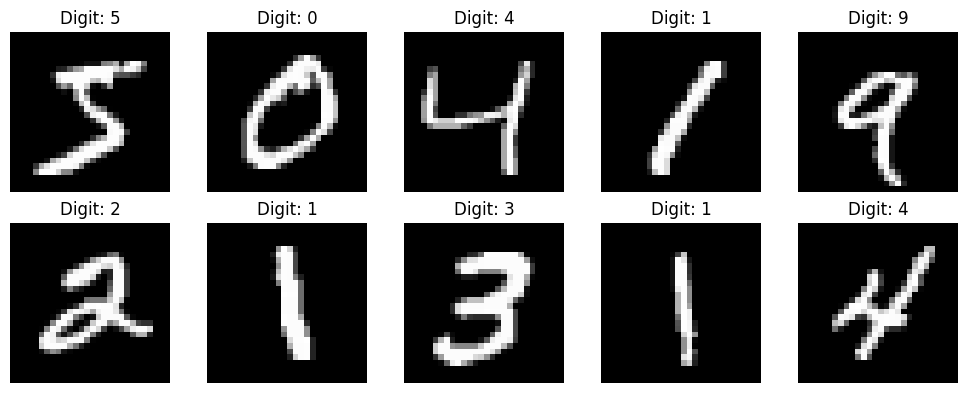

In [4]:
# Display some original MNIST images before training

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title(f"Digit: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Two-Dimensional Latent Space
The latent representation has exactly two coordinates, **z1** and **z2**, so that the learned representations can be displayed on a 2-D scatter plot.


In [5]:
# A 2-D latent space is required for visualisation
LATENT_DIM = 2
print("Latent dimensions:", LATENT_DIM)


Latent dimensions: 2


## Building the Encoder

The encoder receives a 784-dimensional MNIST image.

It processes the image through Dense layers and produces two outputs:

1. z_mean – the mean of the latent distribution
2. z_log_var – the logarithm of the variance of the latent distribution

These two values are used to sample a 2-dimensional latent vector.

In [6]:
# Encoder: image -> hidden representation -> mean and log-variance
encoder_input = layers.Input(shape=(784,), name="image_input")
h = layers.Dense(512, activation="relu")(encoder_input)
h = layers.Dense(256, activation="relu")(h)
z_mean = layers.Dense(LATENT_DIM, name="mean")(h)
z_log_var = layers.Dense(LATENT_DIM, name="log_variance")(h)

encoder = Model(encoder_input, [z_mean, z_log_var], name="encoder")
encoder.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    401,920 │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mean (Dense)        │ (None, 2)         │        514 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ log_variance        │ (None, 2)         │        514 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 534,276 (2.04 MB)

 Trainable params: 534,276 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

## Sampling the Latent Vector
The reparameterisation step combines the encoder mean, variance information, and random Gaussian noise to produce a latent sample while keeping the network trainable.


In [7]:
# Reparameterisation trick
def sample_latent(z_mean, z_log_var):
    noise = tf.random.normal(tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * noise


## Building the Decoder

The decoder takes the 2-dimensional latent vector as input.

It passes this vector through Dense layers and produces 784 output values.

The output is reshaped back into a 28 × 28 image.

Therefore, the decoder converts a point in the latent space into a generated handwritten digit.

In [8]:
# Decoder: 2-D latent vector -> reconstructed MNIST image
decoder_input = layers.Input(shape=(LATENT_DIM,), name="latent_input")
h = layers.Dense(256, activation="relu")(decoder_input)
h = layers.Dense(512, activation="relu")(h)
decoder_output = layers.Dense(784, activation="sigmoid", name="reconstructed_image")(h)

decoder = Model(decoder_input, decoder_output, name="decoder")
decoder.summary()


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ latent_input (InputLayer)       │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstructed_image (Dense)     │ (None, 784)            │       402,192 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 534,544 (2.04 MB)

 Trainable params: 534,544 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

## Building the VAE
The encoder, sampling operation, and decoder are trained together. The objective combines reconstruction loss with KL divergence.


In [9]:
# VAE model with separate reconstruction and KL losses
class MNISTVAE(Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.recon_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.loss_tracker, self.recon_tracker, self.kl_tracker]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            mean, log_var = self.encoder(data, training=True)
            z = sample_latent(mean, log_var)
            output = self.decoder(z, training=True)

            # Sum BCE over all 784 pixels so the loss is on the same scale
            # as the assignment's reconstruction-loss graph.
            output = tf.clip_by_value(output, 1e-7, 1.0 - 1e-7)
            pixel_bce = -(data * tf.math.log(output) +
                          (1.0 - data) * tf.math.log(1.0 - output))
            reconstruction_loss = tf.reduce_mean(tf.reduce_sum(pixel_bce, axis=1))

            kl_per_image = -0.5 * tf.reduce_sum(
                1.0 + log_var - tf.square(mean) - tf.exp(log_var), axis=1
            )
            kl_loss = tf.reduce_mean(kl_per_image)
            total_loss = reconstruction_loss + kl_loss

        gradients = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_variables))

        self.loss_tracker.update_state(total_loss)
        self.recon_tracker.update_state(reconstruction_loss)
        self.kl_tracker.update_state(kl_loss)

        return {
            "loss": self.loss_tracker.result(),
            "reconstruction_loss": self.recon_tracker.result(),
            "kl_loss": self.kl_tracker.result()
        }


## Compiling the VAE

The Adam optimizer is used to train the VAE.

The model will learn by minimizing the total loss, which consists of reconstruction loss and KL divergence loss.

In [10]:
# Create and compile the model
vae = MNISTVAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))
print("VAE is ready for training.")


VAE is ready for training.


## Training
The model is trained for 20 epochs. Reconstruction loss measures how closely the output matches the input, while KL divergence regularises the latent distribution.


In [11]:
# Train for 20 epochs
EPOCHS = 20
BATCH_SIZE = 128

history = vae.fit(
    x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1
)


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - kl_loss: 5.1785 - loss: 185.4575 - reconstruction_loss: 180.2789
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.0828 - loss: 162.7469 - reconstruction_loss: 157.6643
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.4282 - loss: 157.9229 - reconstruction_loss: 152.4947
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 5.6883 - loss: 154.3853 - reconstruction_loss: 148.6969
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 5.8459 - loss: 152.0638 - reconstruction_loss: 146.2179
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - kl_loss: 5.9482 - loss: 150.2992 - reconstruction_loss: 144.3510
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 6.0504 - loss: 149.1379 - reconstruction_loss: 143.0875
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 6.1448 - loss: 147.6933 - reconstruction_loss: 141.5486
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/s

## Final Training Loss

The final values of the total loss, reconstruction loss and KL divergence loss are displayed below.

In [12]:
# Display final losses

final_total_loss = history.history["loss"][-1]
final_reconstruction_loss = history.history["reconstruction_loss"][-1]
final_kl_loss = history.history["kl_loss"][-1]

print("Final Total Loss:", final_total_loss)
print("Final Reconstruction Loss:", final_reconstruction_loss)
print("Final KL Divergence Loss:", final_kl_loss)

Final Total Loss: 140.7853546142578
Final Reconstruction Loss: 134.18646240234375
Final KL Divergence Loss: 6.598921298980713


## Reconstruction Loss
A separate reconstruction-loss curve is plotted against epoch. Because the binary cross-entropy is summed over the 784 pixels, its values are on a larger scale.


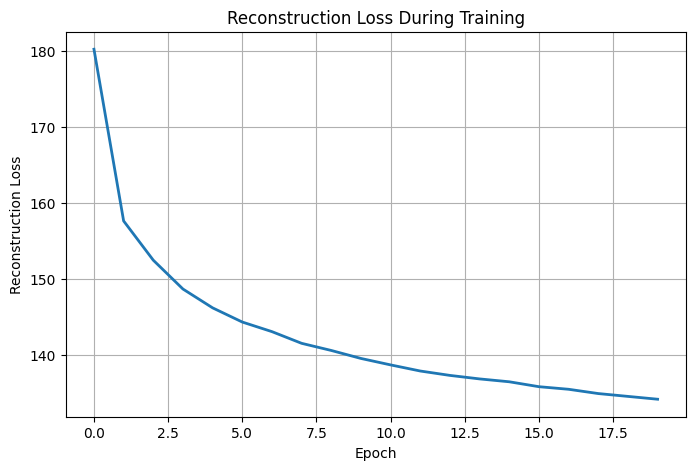

In [13]:
# Plot reconstruction loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["reconstruction_loss"],
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Reconstruction Loss During Training")
plt.grid(True)

plt.show()

## KL Divergence
KL divergence measures how far the learned latent distribution is from the standard normal prior.


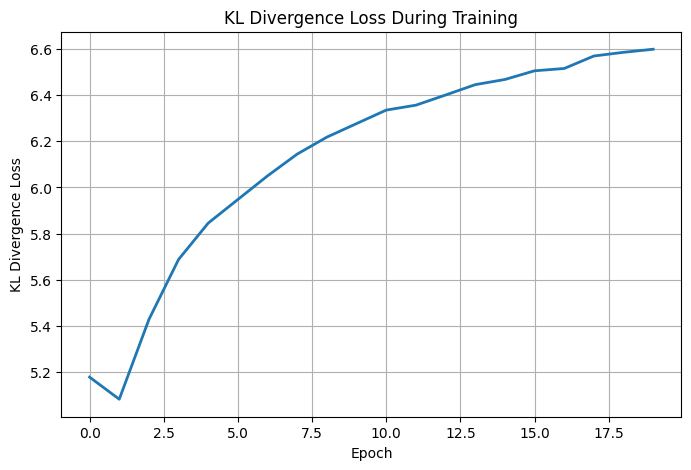

In [14]:
# Plot KL divergence loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["kl_loss"],
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("KL Divergence Loss")
plt.title("KL Divergence Loss During Training")
plt.grid(True)

plt.show()

## Total VAE Loss
The total objective is the sum of reconstruction loss and KL divergence.


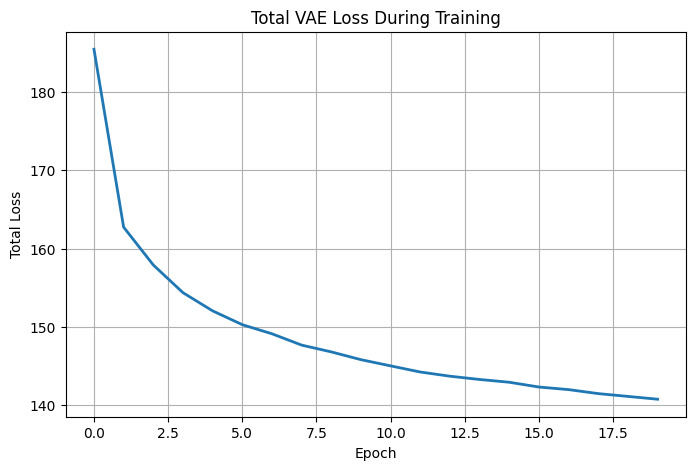

In [15]:
# Plot total loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("Total VAE Loss During Training")
plt.grid(True)

plt.show()

## Encoding the Test Set
The trained encoder maps the test images into two latent coordinates.


In [16]:
# Encode the test set into the two latent coordinates
z_mean_test, z_log_var_test = encoder.predict(x_test, batch_size=256, verbose=0)
print("Latent representation:", z_mean_test.shape)


Latent representation: (10000, 2)


## 2-D Latent-Space Plot
Each test image becomes one point. The point colour represents its MNIST digit label.


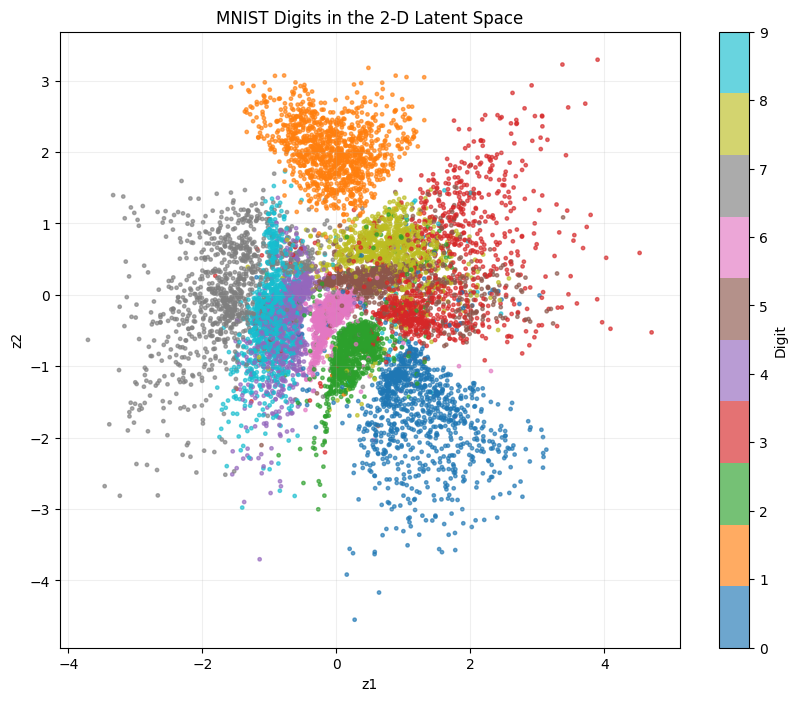

In [17]:
# Display the learned 2-D representation
plt.figure(figsize=(10, 8))
plt.scatter(
    z_mean_test[:, 0], z_mean_test[:, 1],
    c=y_test, cmap="tab10", s=6, alpha=0.65
)
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("MNIST Digits in the 2-D Latent Space")
plt.colorbar(label="Digit")
plt.grid(alpha=0.2)
plt.show()


## Interpretation of the Latent Space

The latent-space plot shows that the VAE learns a structured representation of handwritten digits.

Images belonging to similar digit classes tend to appear closer together in the latent space.

However, the clusters may not be completely separated because some handwritten digits have similar shapes.

For example, digits such as 3 and 8 or 4 and 9 can have similar visual characteristics, so their latent representations may partially overlap.

## Decoding Points Across the Latent Space
A regular grid from approximately -3 to +3 is passed through the decoder to observe how generated digits change as the latent coordinates move.


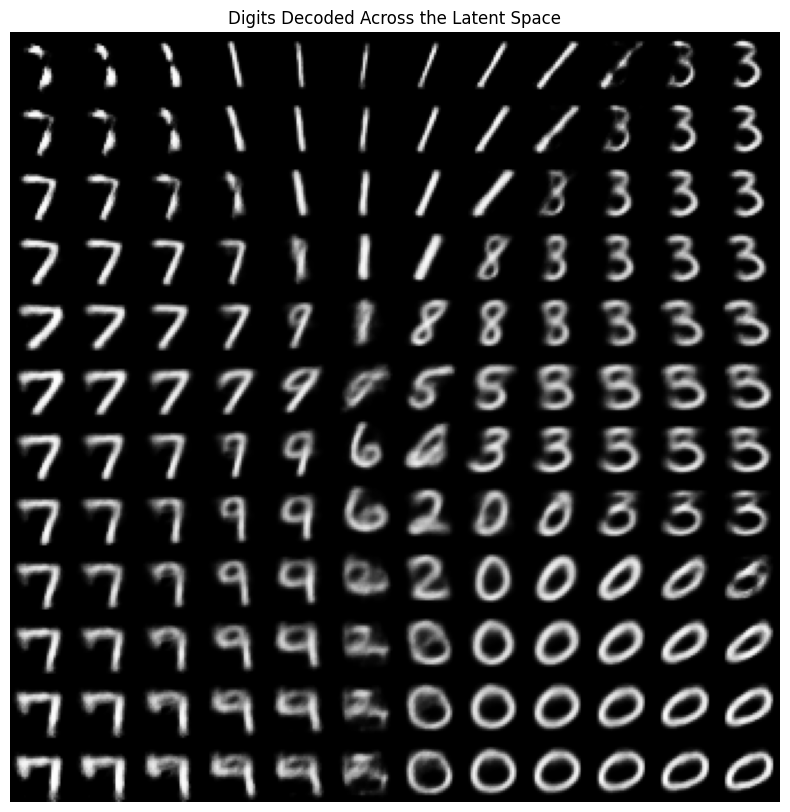

In [18]:
# Decode a regular grid of latent-space points
points = 12
z1 = np.linspace(-3, 3, points)
z2 = np.linspace(3, -3, points)

canvas = np.zeros((28 * points, 28 * points))
for row, y in enumerate(z2):
    for col, x in enumerate(z1):
        latent = np.array([[x, y]], dtype=np.float32)
        image = decoder.predict(latent, verbose=0)[0].reshape(28, 28)
        canvas[row*28:(row+1)*28, col*28:(col+1)*28] = image

plt.figure(figsize=(10, 10))
plt.imshow(canvas, cmap="gray")
plt.axis("off")
plt.title("Digits Decoded Across the Latent Space")
plt.show()


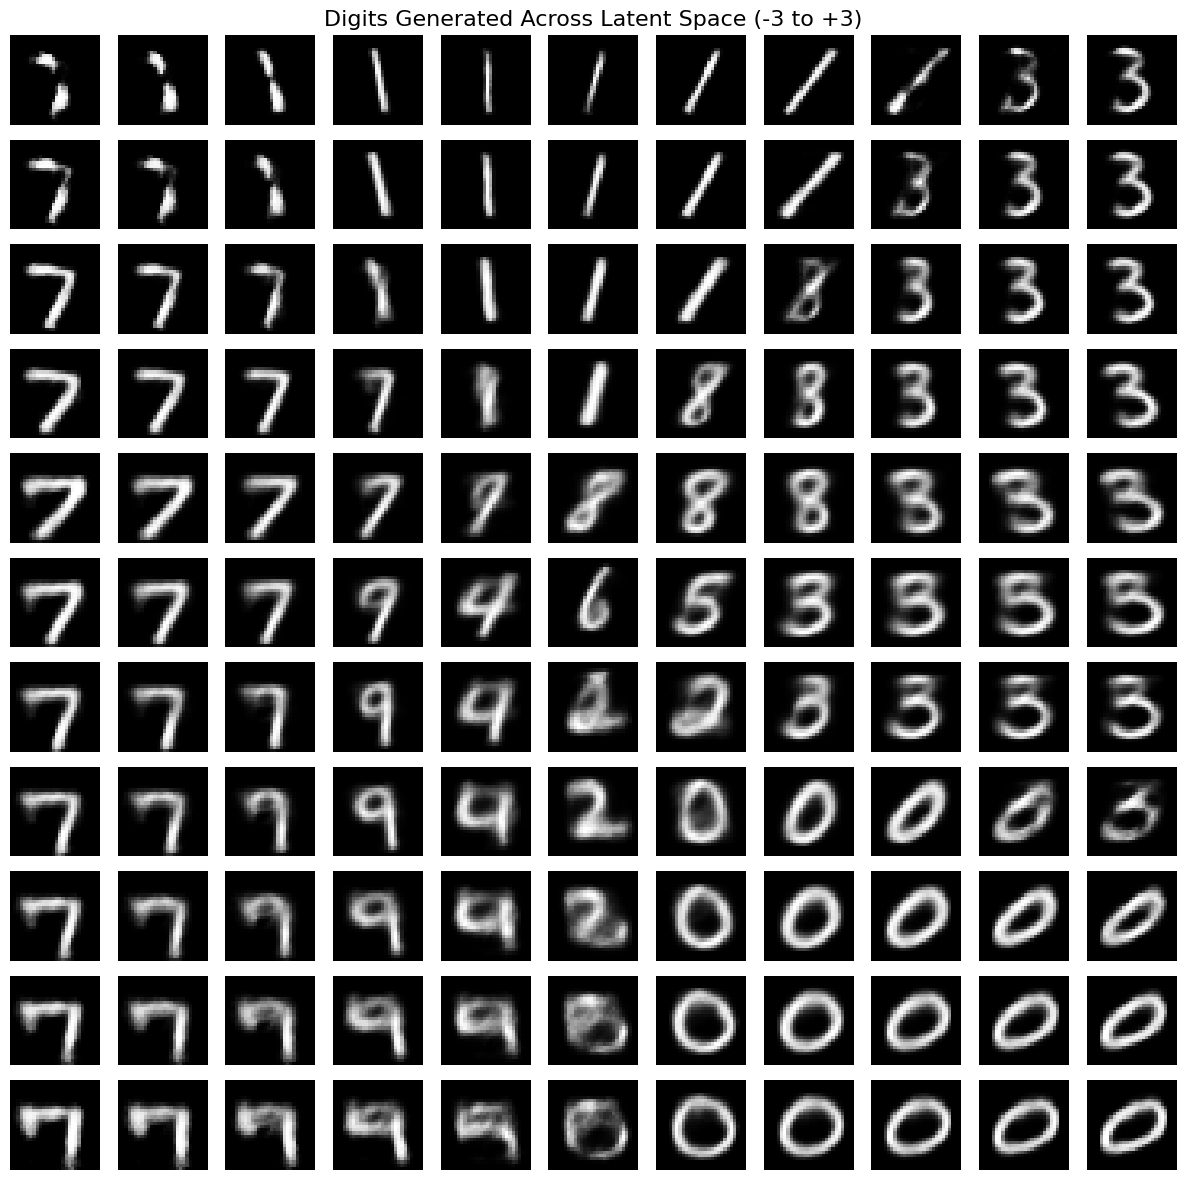

In [19]:
# Display generated digits with latent-space coordinates

n = 11

z1_values = np.linspace(-3, 3, n)
z2_values = np.linspace(3, -3, n)

plt.figure(figsize=(12, 12))

for i, z2 in enumerate(z2_values):

    for j, z1 in enumerate(z1_values):

        z_sample = np.array([[z1, z2]])

        decoded = decoder.predict(
            z_sample,
            verbose=0
        )

        digit = decoded[0].reshape(28, 28)

        ax = plt.subplot(n, n, i * n + j + 1)

        ax.imshow(
            digit,
            cmap="gray"
        )

        ax.axis("off")

plt.suptitle(
    "Digits Generated Across Latent Space (-3 to +3)",
    fontsize=16
)

plt.tight_layout()
plt.show()

## Random Latent Samples
Additional digit images are generated from randomly sampled points in the latent distribution.


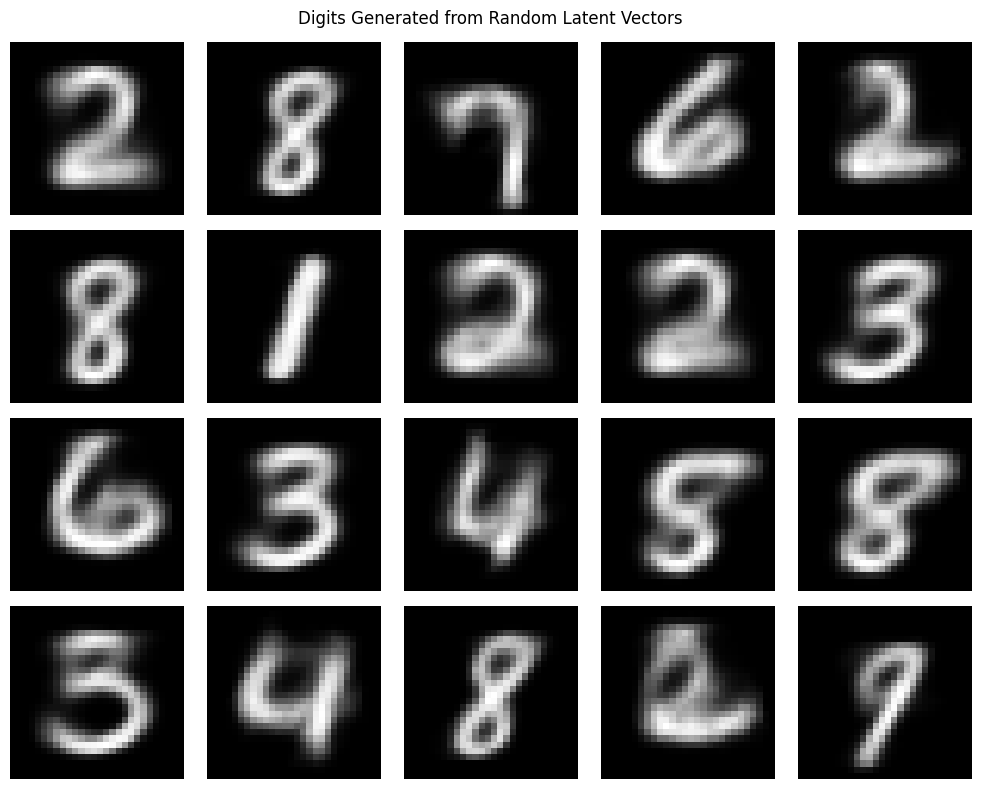

In [20]:
# Generate digits from random points sampled from N(0, I)
rng = np.random.default_rng(42)
random_z = rng.normal(0, 1, size=(20, LATENT_DIM)).astype(np.float32)
new_digits = decoder.predict(random_z, verbose=0)

plt.figure(figsize=(10, 8))
for i, image in enumerate(new_digits):
    plt.subplot(4, 5, i + 1)
    plt.imshow(image.reshape(28, 28), cmap="gray")
    plt.axis("off")
plt.suptitle("Digits Generated from Random Latent Vectors")
plt.tight_layout()
plt.show()


## Original vs Reconstructed Images
A small set of test images is reconstructed to visually inspect the VAE output.


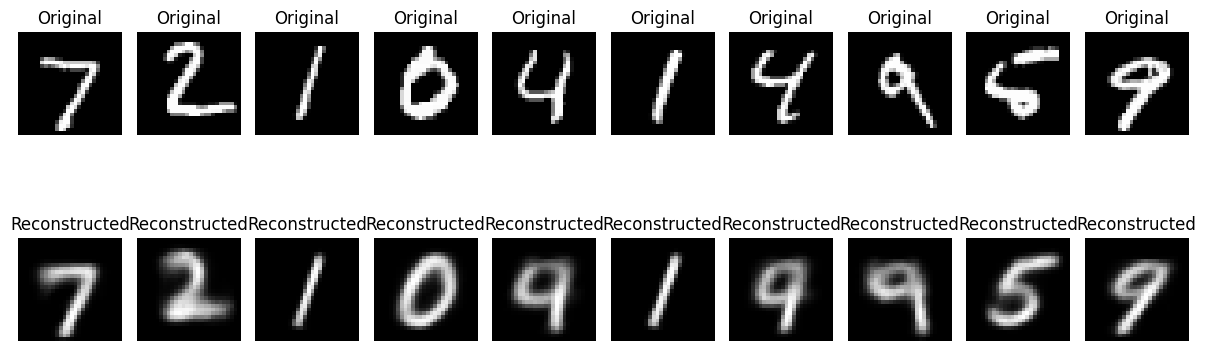

In [21]:
# Compare original test digits with their reconstructions
mean, log_var = encoder.predict(x_test[:10], verbose=0)
z = sample_latent(mean, log_var)
recon = decoder.predict(z, verbose=0)

plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    plt.title("Original")

    plt.subplot(2, 10, i + 11)
    plt.imshow(recon[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    plt.title("Reconstructed")
plt.tight_layout()
plt.show()


Observations
1. Do similar digits form clusters?

Yes. Digits with similar shapes tend to form groups or clusters in the 2D latent space. For example, visually similar digits such as 3 and 8 or 4 and 9 may appear closer to each other.

2. Are the clusters clearly separated?

Most digit groups show some separation, but the clusters are not completely distinct. Some overlap occurs between digits with similar shapes. This indicates that the VAE has learned meaningful features of the handwritten digits, while some representations remain similar.

3. How do generated digits change when moving gradually through the latent space?

As we move gradually from one point to another in the latent space, the generated digits change progressively in their shape and structure. The model can transform one digit-like pattern into another rather than changing suddenly.

4. Does the transition between generated images appear smooth?

Yes. The generated images generally show smooth transitions between neighbouring latent points. This demonstrates that the VAE has learned a continuous latent representation in which nearby points produce visually similar digit images.

# Conclusion
The Variational Autoencoder successfully learned a 2-dimensional latent representation of the MNIST dataset. Similar digits formed meaningful groups in the latent space, although some overlap was observed between visually similar digits. By moving through the latent space, new digit images could be generated with gradual and smooth changes in their shapes. Overall, the results demonstrate that the VAE can learn a structured and continuous representation of handwritten digits and generate new digit-like images from different latent-space positions.